In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,210 (47.70 KB)

 Trainable params: 12,210 (47.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 17s 676us/step - accuracy: 0.6433 - loss: 0.8002
Epoch 2/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 17s 676us/step - accuracy: 0.8931 - loss: 0.3054
Epoch 3/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 17s 683us/step - accuracy: 0.9761 - loss: 0.0977
Epoch 4/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 17s 697us/step - accuracy: 0.9902 - loss: 0.0495
Epoch 5/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 18s 702us/step - accuracy: 0.9925 - loss: 0.0384
Epoch 6/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 18s 712us/step - accuracy: 0.9938 - loss: 0.0322
Epoch 7/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 18s 719us/step - accuracy: 0.9944 - loss: 0.0288
Epoch 8/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 18s 728us/step - accuracy: 0.9947 - loss: 0.0270
Epoch 9/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 18s 733us/step - accuracy: 0.9952 - loss: 0.0247
Epoch 10/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 19s 739us/step - accuracy: 0.9952 - loss: 0.0242
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 12s 465us/step
Accuracy : 0.9972
Rec

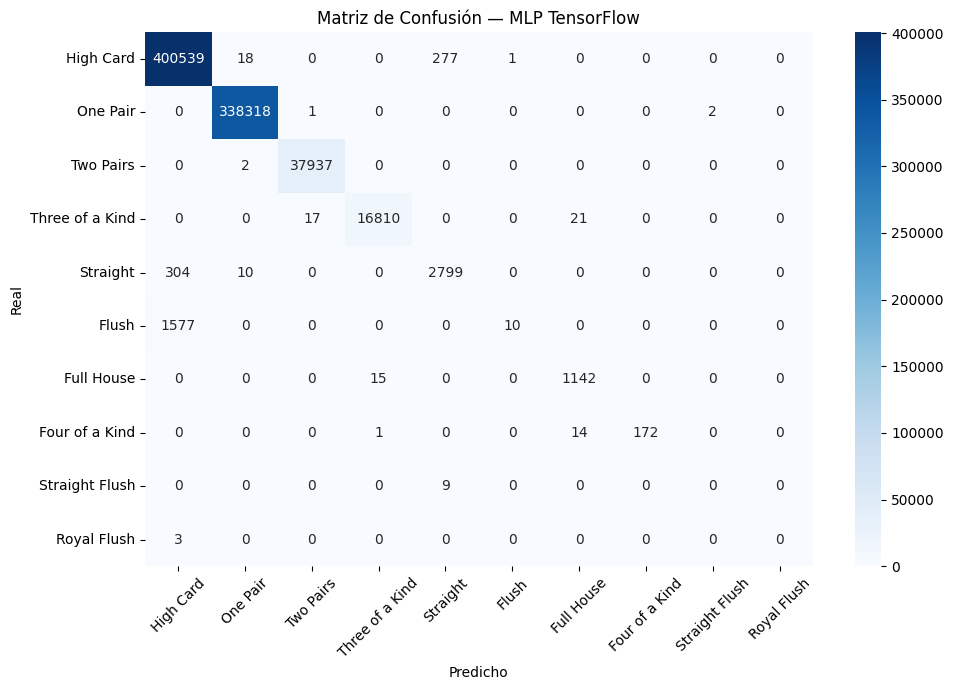

In [7]:
# Se lee el dataset preprocesado
#df = pd.read_csv('../../preprocesamiento/preprocesamiento_trainning.data', header=None)
df = pd.read_csv('../../dataset/train.data', header=None)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]
clases = sorted(y.unique().astype(int).tolist())
clase_nombres = {
    0: "High Card", 1: "One Pair", 2: "Two Pairs", 3: "Three of a Kind",
    4: "Straight",  5: "Flush",   6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}
nombres_ordenados = [clase_nombres[c] for c in clases]


x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Número de clases distintas
# Número de características (features) por muestra
n_clases = len(np.unique(y))
n_features = x.shape[1]


modelo_tf = keras.Sequential([    
    # Capa de entrada: recibe vectores de tamaño n_features
    keras.layers.Input(shape=(n_features,)),
    # Primera capa oculta con 10 neuronas y activación ReLU
    keras.layers.Dense(100, activation='relu'),
    # Segunda capa oculta con 10 neuronas y activación ReLU
    keras.layers.Dense(100, activation='relu'),
    # Capa de salida:
    # n_clases neuronas (una por clase)
    # softmax convierte las salidas en probabilidades
    keras.layers.Dense(n_clases, activation='softmax')
])

# Compilación del modelo:
modelo_tf.compile(
    optimizer='adam',  # algoritmo de optimización
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']  # métrica de evaluación
)

# Muestra un resumen del modelo (capas, parámetros, etc.)
modelo_tf.summary()


history = modelo_tf.fit(
    x, y,
    epochs=10,          # número de iteraciones completas sobre el dataset
    batch_size=32,      # tamaño de lote
    verbose=1           # muestra progreso en consola
)

# Predicciones del modelo (probabilidades por clase)
y_pred_tf = np.argmax(modelo_tf.predict(x), axis=1)

# Se usa argmax para convertir probabilidades en la clase con mayor valor


# Accuracy: proporción de aciertos
print(f"Accuracy : {accuracy_score(y, y_pred_tf):.4f}")
# Recall macro: promedio del recall por clase (útil en datasets desbalanceados)
print(f"Recall   : {recall_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")
# F1-score macro: balance entre precisión y recall por clase
print(f"F1       : {f1_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")


# Calcula la matriz de confusión
cm_tf = confusion_matrix(y, y_pred_tf)

# Se grafica con seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_tf, 
    annot=True,        # muestra números dentro de cada celda
    fmt='d',           # formato entero
    cmap='Blues',      # esquema de colores
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)

# Etiquetas del gráfico
plt.title("Matriz de Confusión — MLP TensorFlow")
plt.xlabel("Predicho")
plt.ylabel("Real")

# Ajustes visuales
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [9]:
modelo_tf.save("modelo_poker_raw.keras")